# Compare Temperature / Heat Content

In this Notebook, I want to make a plot that compares the final temperature profile/heat content for several MITgcm simulations.

In [2]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Retrieve Data

We loop through the model runs. For each model run, we load the data, retrieve the data that we want to keep and discard the rest.

In [26]:

model_runs = [f"MIZ{i:03d}" for i in range(9,16)] # model runs to loop through
delta_t = 4 # time step in seconds
output_dir = "../../MITgcm/so_plumes/"

final_avg_T_wholedomain = pd.DataFrame() 
final_avg_T_openwater = pd.DataFrame() 

final_avg_S_wholedomain = pd.DataFrame() 
final_avg_S_openwater = pd.DataFrame() 

final_avg_N2_wholedomain = pd.DataFrame() 
final_avg_N2_openwater = pd.DataFrame() 

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    for i in range(len(model_runs)):
        run = model_runs[i]
        
        # open dataset
        ds = open_mdsdataset(output_dir+run, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")
        # openwater subdomain
        ds_openwater = ds.isel(YC = slice(0,50))
        # select last time step
        ds_end = ds.isel(time = -1)
        ds_openwater_end = ds_openwater.isel(time=-1)

        if i == 0:
            # set depth as index
            index = pd.Index(ds.Z, name = "depth")
            final_avg_T_wholedomain.index = index
            final_avg_T_openwater.index = index
            final_avg_S_wholedomain.index = index
            final_avg_S_openwater.index = index
            
            # average T profile from initial conditions
            final_avg_T_wholedomain["initCond"] = ds_openwater.isel(time=0).T.mean(dim = ["YC","XC"])
            final_avg_T_openwater["initCond"] = ds_openwater.isel(time=0).T.mean(dim = ["YC","XC"])

            # average S profile from initial conditions
            final_avg_S_wholedomain["initCond"] = ds_openwater.isel(time=0).S.mean(dim = ["YC","XC"])
            final_avg_S_openwater["initCond"] = ds_openwater.isel(time=0).S.mean(dim = ["YC","XC"])
            
        # calculate mean final temperature profile
        final_avg_T_wholedomain[run] = ds_end.T.mean(dim = ["YC","XC"])
        final_avg_T_openwater[run] = ds_openwater_end.T.mean(dim = ["YC","XC"])

        # calculate mean final salinity profile
        final_avg_S_wholedomain[run] = ds_end.S.mean(dim = ["YC","XC"])
        final_avg_S_openwater[run] = ds_openwater_end.S.mean(dim = ["YC","XC"])
    
final_avg_T_wholedomain.head()

,initCond,MIZ009,MIZ010,MIZ011,MIZ012,MIZ013,MIZ014,MIZ015
depth,,,,,,,,
-0.50,-1.86173,-1.945979,-1.912730,-1.957592,-1.939284,-1.946935,-1.887208,-1.959180
-1.55,-1.86173,-1.937271,-1.906087,-1.952102,-1.931910,-1.937710,-1.884240,-1.951072
-2.70,-1.86173,-1.936814,-1.904655,-1.953206,-1.934178,-1.935285,-1.883500,-1.949836
-3.90,-1.86173,-1.937319,-1.905125,-1.952357,-1.934809,-1.934272,-1.882991,-1.949094
-5.15,-1.86173,-1.937902,-1.906114,-1.951623,-1.934375,-1.934525,-1.882991,-1.948605


## Plot Average Temperature Profiles

Text(0.5, 0.98, 'Final Average Temperature Profile after 48h\n\nOver Whole Domain:\n')

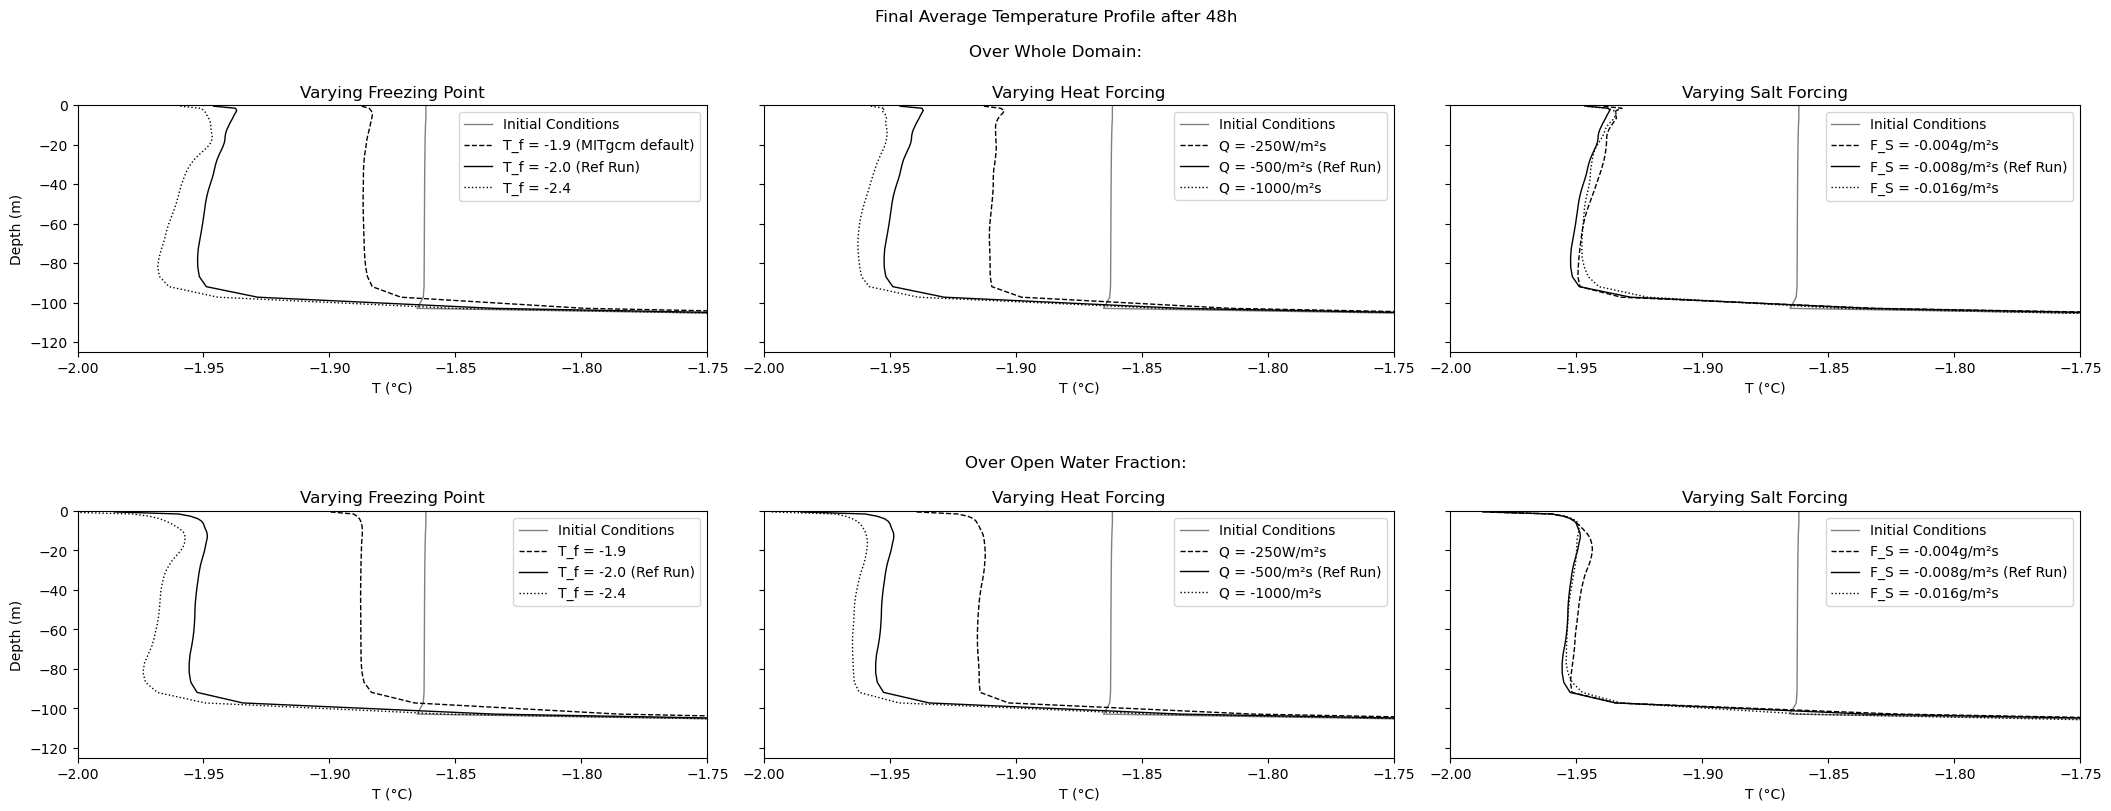

In [134]:
# both in one plot

fig, axs = plt.subplots(2,3, figsize = (21,8), sharex = False, sharey = True, constrained_layout = True)
plt.rcParams['lines.linewidth'] = 1

# WHOLE DOMAIN

# freezing point variations
axs[0,0].set_title("Varying Freezing Point")
axs[0,0].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,0].plot(final_avg_T_wholedomain.MIZ014, final_avg_T_wholedomain.index, label = "T_f = -1.9 (MITgcm default)", color = "black", linestyle = "dashed")
axs[0,0].plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[0,0].plot(final_avg_T_wholedomain.MIZ015, final_avg_T_wholedomain.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[0,0].set_ylabel("Depth (m)")

# heat flux variations
axs[0,1].set_title("Varying Heat Forcing")
axs[0,1].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,1].plot(final_avg_T_wholedomain.MIZ010, final_avg_T_wholedomain.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[0,1].plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[0,1].plot(final_avg_T_wholedomain.MIZ011, final_avg_T_wholedomain.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")

# salt forcing variation
axs[0,2].set_title("Varying Salt Forcing")
axs[0,2].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,2].plot(final_avg_T_wholedomain.MIZ012, final_avg_T_wholedomain.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[0,2].plot(final_avg_T_wholedomain.MIZ009, final_avg_T_wholedomain.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black")
axs[0,2].plot(final_avg_T_wholedomain.MIZ013, final_avg_T_wholedomain.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")

# OPEN WATER FRACTION
# freezing point variations
axs[1,0].set_title("Varying Freezing Point")
axs[1,0].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,0].plot(final_avg_T_openwater.MIZ014, final_avg_T_openwater.index, label = "T_f = -1.9", color = "black", linestyle = "dashed")
axs[1,0].plot(final_avg_T_openwater.MIZ009, final_avg_T_openwater.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[1,0].plot(final_avg_T_openwater.MIZ015, final_avg_T_openwater.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[1,0].set_ylabel("Depth (m)")
axs[1,0].set_xlabel("T (°C)")


# heat flux variations
axs[1,1].set_title("\n\n\nOver Open Water Fraction: \n\nVarying Heat Forcing")
axs[1,1].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,1].plot(final_avg_T_openwater.MIZ010, final_avg_T_openwater.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[1,1].plot(final_avg_T_openwater.MIZ009, final_avg_T_openwater.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[1,1].plot(final_avg_T_openwater.MIZ011, final_avg_T_openwater.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")
axs[1,1].set_xlabel("T (°C)")


# salt forcing variation
axs[1,2].set_title("Varying Salt Forcing")
axs[1,2].plot(final_avg_T_wholedomain.initCond, final_avg_T_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,2].plot(final_avg_T_openwater.MIZ012, final_avg_T_openwater.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[1,2].plot(final_avg_T_openwater.MIZ009, final_avg_T_openwater.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black", linewidth = 1)
axs[1,2].plot(final_avg_T_openwater.MIZ013, final_avg_T_openwater.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")
axs[1,2].set_xlabel("T (°C)")


for ax in axs.flatten():
    ax.legend()
    ax.set_ylim(-125,0)
    ax.set_xlim(-2,-1.75)
    ax.set_xlabel("T (°C)")
    

plt.suptitle("Final Average Temperature Profile after 48h\n\nOver Whole Domain:\n")


## Plot Average Salinity Profiles

Text(0.5, 0.98, 'Final Average Salinity Profile after 48h\n\nOver Whole Domain:\n')

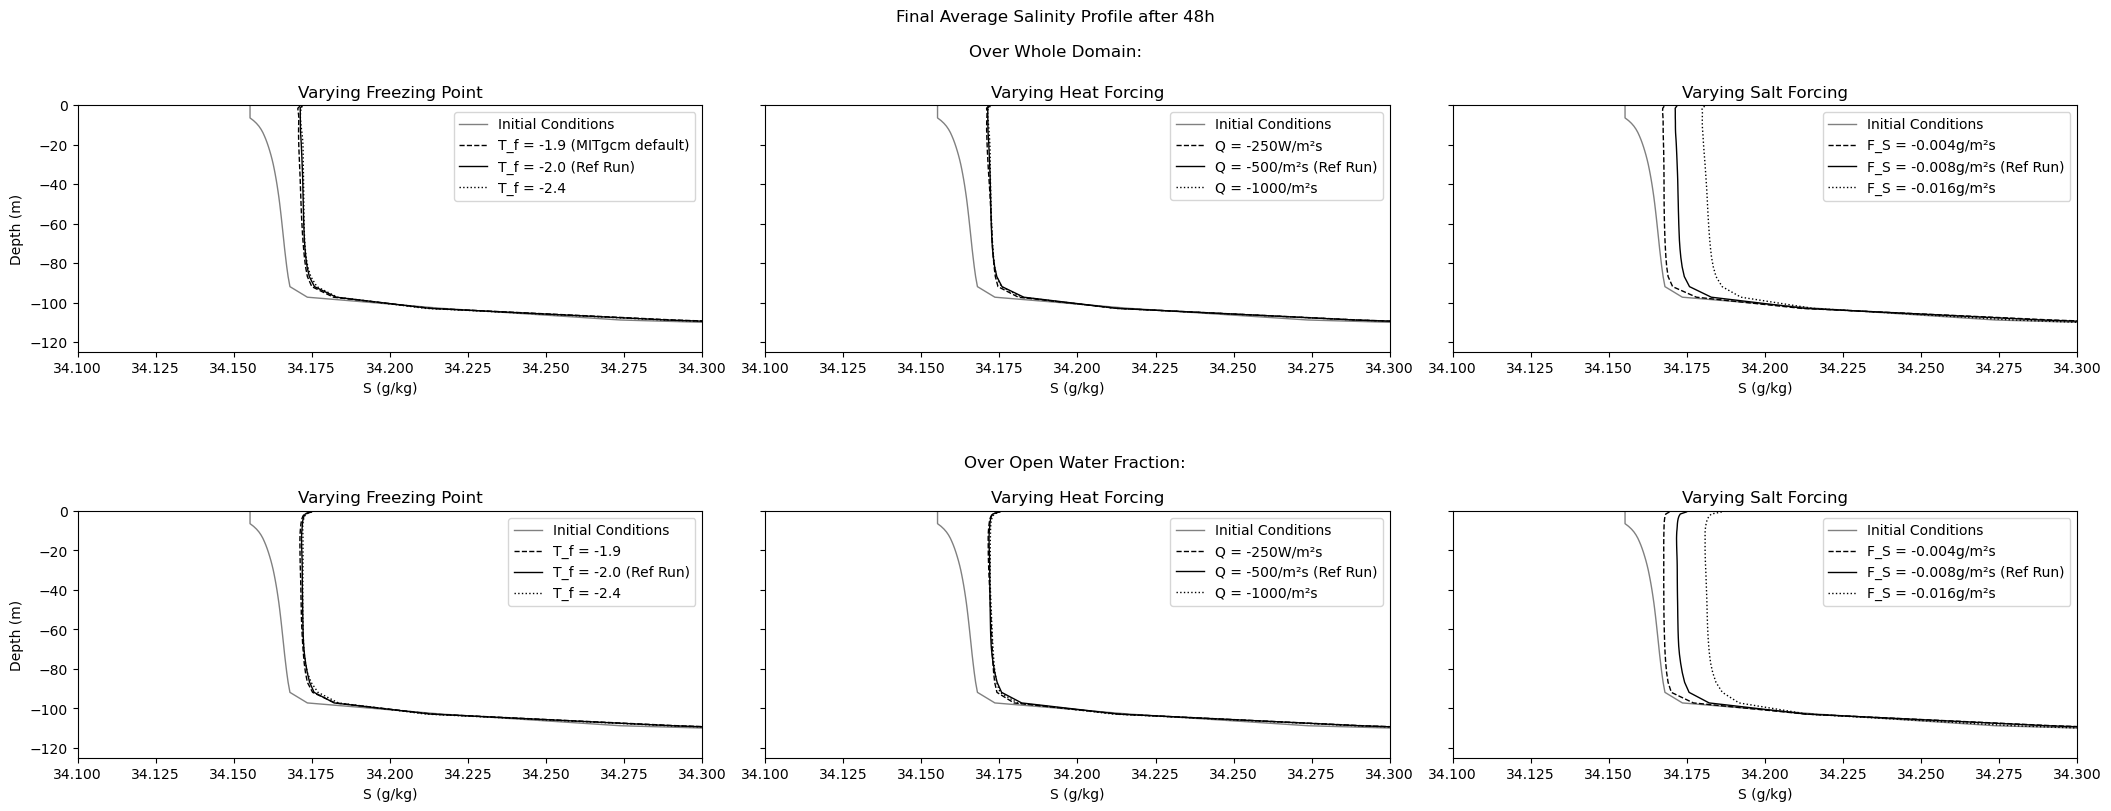

In [135]:
# both in one plot

fig, axs = plt.subplots(2,3, figsize = (21,8), sharex = False, sharey = True, constrained_layout = True)
plt.rcParams['lines.linewidth'] = 1

# WHOLE DOMAIN

# freezing point variations
axs[0,0].set_title("Varying Freezing Point")
axs[0,0].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,0].plot(final_avg_S_wholedomain.MIZ014, final_avg_S_wholedomain.index, label = "T_f = -1.9 (MITgcm default)", color = "black", linestyle = "dashed")
axs[0,0].plot(final_avg_S_wholedomain.MIZ009, final_avg_S_wholedomain.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[0,0].plot(final_avg_S_wholedomain.MIZ015, final_avg_S_wholedomain.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[0,0].set_ylabel("Depth (m)")

# heat flux variations
axs[0,1].set_title("Varying Heat Forcing")
axs[0,1].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,1].plot(final_avg_S_wholedomain.MIZ010, final_avg_S_wholedomain.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[0,1].plot(final_avg_S_wholedomain.MIZ009, final_avg_S_wholedomain.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[0,1].plot(final_avg_S_wholedomain.MIZ011, final_avg_S_wholedomain.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")

# salt forcing variation
axs[0,2].set_title("Varying Salt Forcing")
axs[0,2].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[0,2].plot(final_avg_S_wholedomain.MIZ012, final_avg_S_wholedomain.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[0,2].plot(final_avg_S_wholedomain.MIZ009, final_avg_S_wholedomain.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black")
axs[0,2].plot(final_avg_S_wholedomain.MIZ013, final_avg_S_wholedomain.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")

# OPEN WATER FRACTION
# freezing point variations
axs[1,0].set_title("Varying Freezing Point")
axs[1,0].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,0].plot(final_avg_S_openwater.MIZ014, final_avg_S_openwater.index, label = "T_f = -1.9", color = "black", linestyle = "dashed")
axs[1,0].plot(final_avg_S_openwater.MIZ009, final_avg_S_openwater.index, label = "T_f = -2.0 (Ref Run)", color = "black")
axs[1,0].plot(final_avg_S_openwater.MIZ015, final_avg_S_openwater.index, label = "T_f = -2.4", color = "black", linestyle = "dotted")
axs[1,0].set_ylabel("Depth (m)")
axs[1,0].set_xlabel("S (g/kg)")


# heat flux variations
axs[1,1].set_title("\n\n\nOver Open Water Fraction: \n\nVarying Heat Forcing")
axs[1,1].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,1].plot(final_avg_S_openwater.MIZ010, final_avg_S_openwater.index, label = "Q = -250W/m²s", color = "black", linestyle = "dashed")
axs[1,1].plot(final_avg_S_openwater.MIZ009, final_avg_S_openwater.index, label = "Q = -500/m²s (Ref Run)", color = "black")
axs[1,1].plot(final_avg_S_openwater.MIZ011, final_avg_S_openwater.index, label = "Q = -1000/m²s", color = "black", linestyle = "dotted")
axs[1,1].set_xlabel("S (g/kg)")


# salt forcing variation
axs[1,2].set_title("Varying Salt Forcing")
axs[1,2].plot(final_avg_S_wholedomain.initCond, final_avg_S_wholedomain.index, label = "Initial Conditions", color = "grey")
axs[1,2].plot(final_avg_S_openwater.MIZ012, final_avg_S_openwater.index, label = "F_S = -0.004g/m²s", color = "black", linestyle = "dashed")
axs[1,2].plot(final_avg_S_openwater.MIZ009, final_avg_S_openwater.index, label = "F_S = -0.008g/m²s (Ref Run)", color = "black", linewidth = 1)
axs[1,2].plot(final_avg_S_openwater.MIZ013, final_avg_S_openwater.index, label = "F_S = -0.016g/m²s", color = "black", linestyle = "dotted")
axs[1,2].set_xlabel("S (g/kg)")


for ax in axs.flatten():
    ax.legend()
    ax.set_ylim(-125,0)
    ax.set_xlim(34.1,34.3)
    ax.set_xlabel("S (g/kg)")
    

plt.suptitle("Final Average Salinity Profile after 48h\n\nOver Whole Domain:\n")


## Calculate and Plot N²